In [1]:
import pandas as pd

df = pd.read_csv("water.csv")

df.head()


,complaint_text,department,sentiment
0,No water supply in our area since morning,Water,Critical
1,Water pipeline broken near market,Water,Critical
2,Dirty muddy water coming from taps,Water,Critical
3,Low water pressure in building,Water,Negative
4,Water leakage wasting huge amount of water,Water,Negative


In [2]:
# Check missing values
df.isnull().sum()


complaint_text     0
department         0
sentiment         16
dtype: int64

In [3]:
# Dataset information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   complaint_text  236 non-null    str  
 1   department      236 non-null    str  
 2   sentiment       220 non-null    str  
dtypes: str(3)
memory usage: 5.7 KB


In [4]:
# Show sentiment counts
df["sentiment"].value_counts()


sentiment
Critical    81
Negative    74
Positive    35
Neutral     30
Name: count, dtype: int64

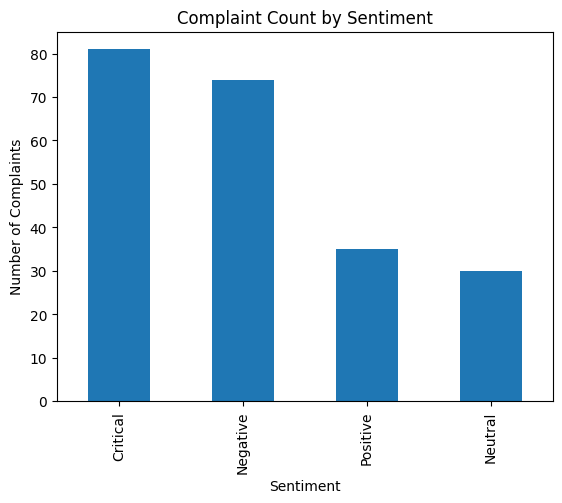

In [5]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Complaint Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Complaints")

plt.show()


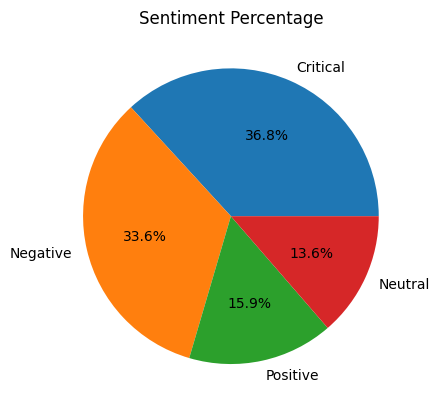

In [6]:
df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sentiment Percentage")
plt.ylabel("")

plt.show()


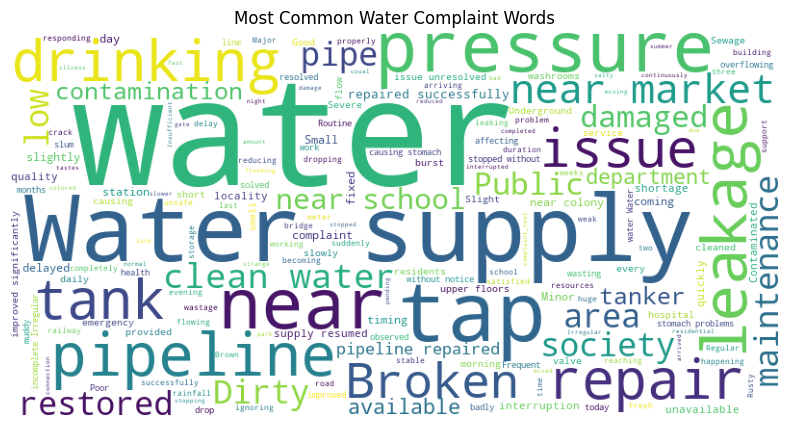

In [7]:
from wordcloud import WordCloud

text = " ".join(df["complaint_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Water Complaint Words")
plt.show()

In [8]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("water.csv")

# Remove missing/blank values
df = df.dropna()

# Features and target
X = df["complaint_text"].astype(str)
y = df["sentiment"].astype(str)

# Convert text to numbers
vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    stop_words="english",
    max_features=3000
)

X_vectorized = vectorizer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.1,
    random_state=42
)

# Train model
model = LogisticRegression(
    max_iter=3000,
    C=2
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

Model Accuracy: 81.81818181818183 %


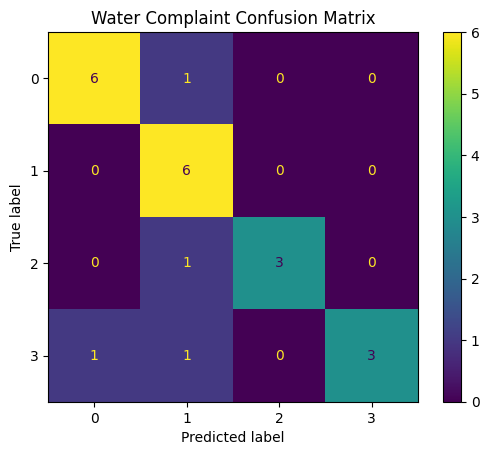

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Water Complaint Confusion Matrix")
plt.show()

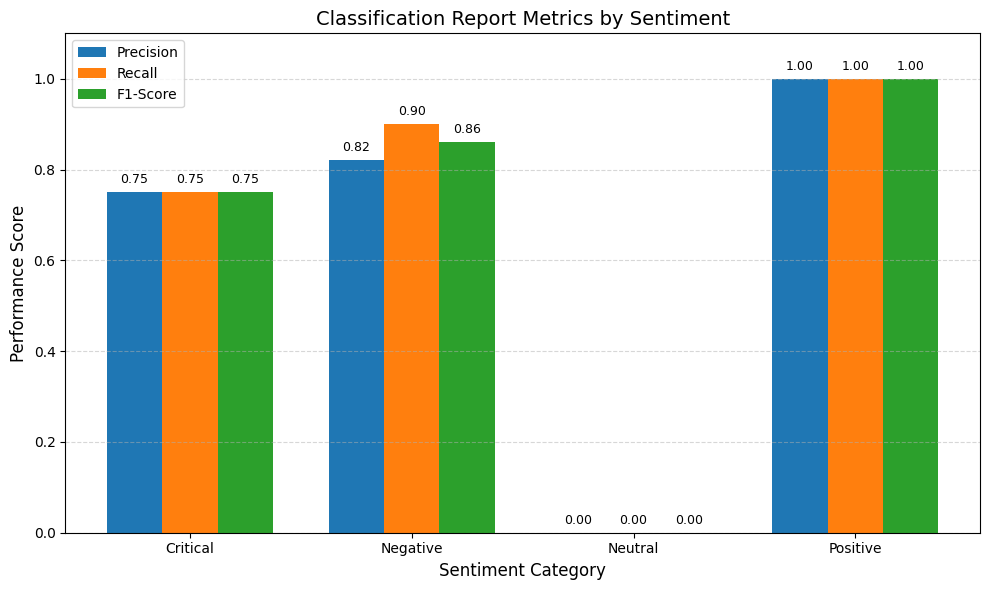

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Sentiment classes
classes = ['Critical', 'Negative', 'Neutral', 'Positive']

# Metrics values
precision = [0.75, 0.82, 0.00, 1.00]
recall = [0.75, 0.90, 0.00, 1.00]
f1_score = [0.75, 0.86, 0.00, 1.00]

# X-axis positions
x = np.arange(len(classes))
width = 0.25

# Create figure
plt.figure(figsize=(10, 6))

# Plot bars
bars1 = plt.bar(x - width, precision, width, label='Precision')
bars2 = plt.bar(x, recall, width, label='Recall')
bars3 = plt.bar(x + width, f1_score, width, label='F1-Score')

# Labels and title
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Performance Score', fontsize=12)
plt.title('Classification Report Metrics by Sentiment', fontsize=14)
plt.xticks(x, classes)
plt.ylim(0, 1.1)

# Add values on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval + 0.02,
            f'{yval:.2f}',
            ha='center',
            fontsize=9
        )

# Legend and grid
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save graph (optional)
plt.savefig("classification_metrics.png", dpi=300)

# Show graph
plt.tight_layout()
plt.show()

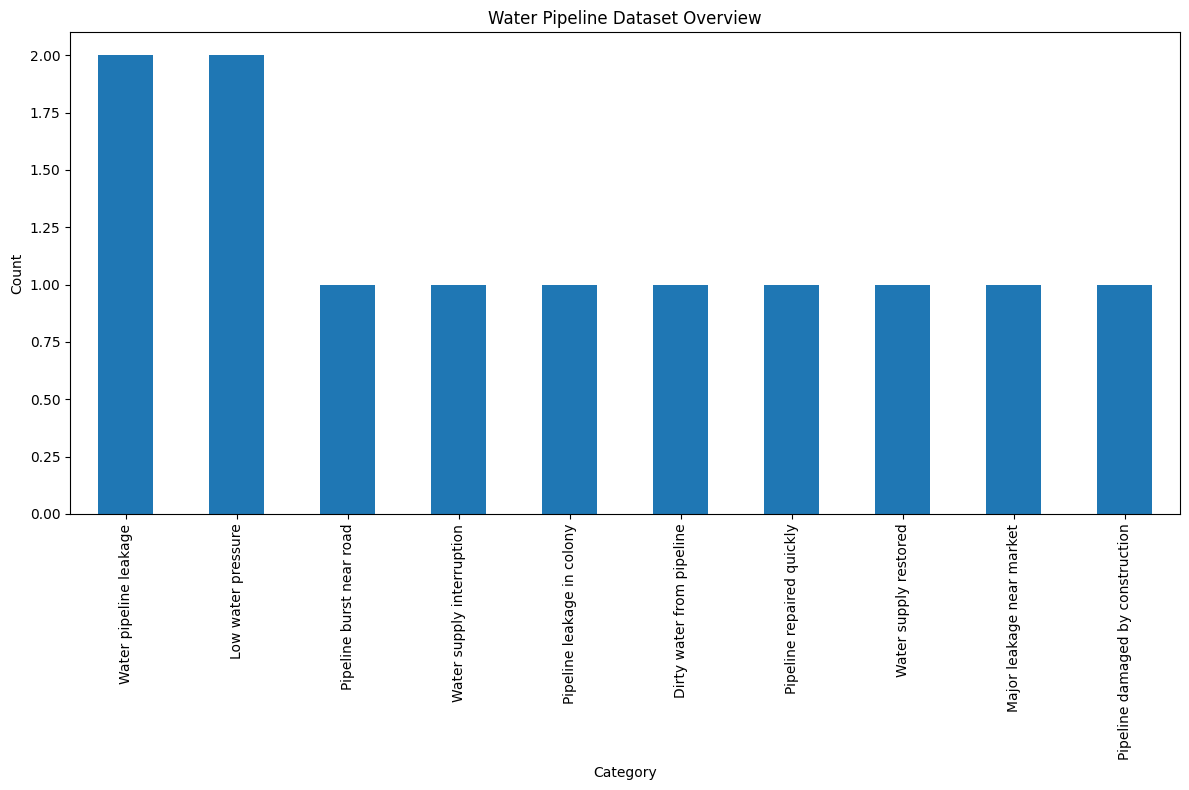

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample Water Pipeline complaints dataset
data = {
    "Complaint": [
        "Water pipeline leakage",
        "Pipeline burst near road",
        "Low water pressure",
        "Water supply interruption",
        "Pipeline leakage in colony",
        "Dirty water from pipeline",
        "Pipeline repaired quickly",
        "Water supply restored",
        "Major leakage near market",
        "Pipeline damaged by construction",
        "Water pipeline leakage",
        "Low water pressure"
    ]
}

df = pd.DataFrame(data)

# Count occurrences
complaint_counts = df["Complaint"].value_counts()

# Plot
plt.figure(figsize=(12, 8))
complaint_counts.plot(kind='bar')

plt.title("Water Pipeline Dataset Overview")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

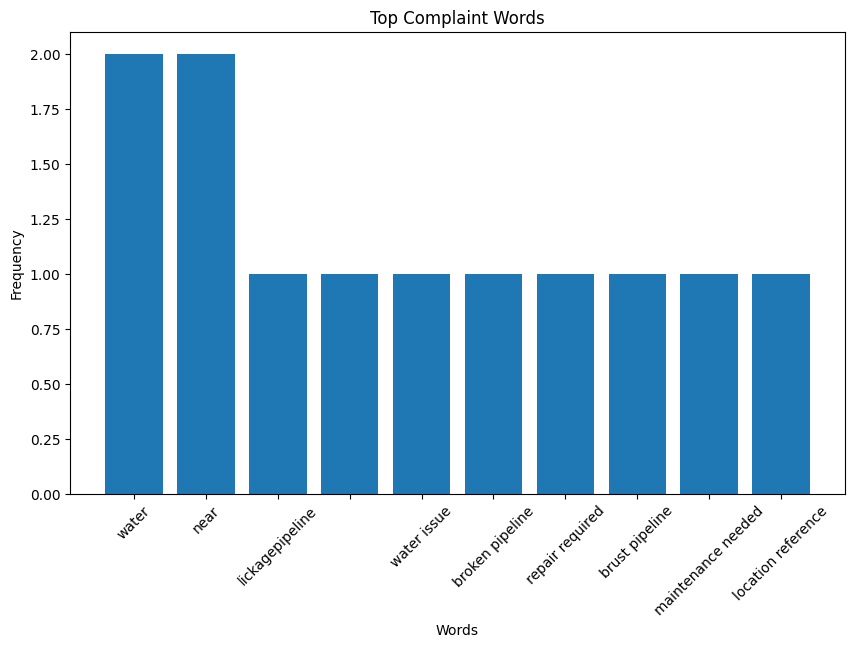

In [12]:
import matplotlib.pyplot as plt
from collections import Counter

# Example complaint words
words = [
    'water','water','near','near','lickagepipeline','',
    'water issue','broken pipeline','repair required','brust pipeline','maintenance needed','location reference'
]

# Count word frequencies
word_counts = Counter(words)

# Get top 10 words
top_words = word_counts.most_common(10)

# Separate words and counts
labels = [word for word, count in top_words]
counts = [count for word, count in top_words]

# Plot
plt.figure(figsize=(10, 6))
plt.bar(labels, counts)
plt.title("Top Complaint Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()
